### **Environment Setup**

In [1]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from scipy.stats import f

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def plot_mse_vs_rhat_9(
    name,
    df,
    warmup,
    HighlightIdx1,
    HighlightIdx2,
    bound,
    threshold,
    num_chains_short,
    num_super_chains
):
    if len(warmup) != 9:
        raise ValueError("warmup must contain exactly 9 values.")

    # ==============================================
    # K, M, and F-derived Rhat boundaries
    # ==============================================

    K = num_super_chains
    M = num_chains_short / num_super_chains

    if M <= 1 or K <= 1:
        raise ValueError("K and M must both be greater than 1.")

    df1 = K - 1
    df2 = K * (M - 1)

    f_low = f.ppf(0.05, df1, df2)
    f_high = f.ppf(0.95, df1, df2)

    rhat_low = np.sqrt(1 + f_low / M) - 1
    rhat_high = np.sqrt(1 + f_high / M) - 1

    # ==============================================
    # Figure setup
    # ==============================================

    fig, axes = plt.subplots(
        3, 3,
        figsize=(22, 15),
        dpi=150,
        sharex=True,
        sharey=True
    )
    axes = axes.flatten()

    # ==============================================
    # Highlight groups
    # ==============================================

    idx1 = set(HighlightIdx1)
    idx2 = set(HighlightIdx2) - idx1

    # ==============================================
    # Plot each warmup
    # ==============================================

    for i, w in enumerate(warmup):

        ax = axes[i]

        df_warmup = df[
            df["Warmup Length"] == w
        ].copy()

        if df_warmup.empty:
            raise ValueError(
                f"No data found for Warmup Length = {w}."
            )

        # ------------------------------------------
        # Separate groups
        # ------------------------------------------

        highest = df_warmup[
            df_warmup["Dimension"].isin(idx1)
        ]

        medium = df_warmup[
            df_warmup["Dimension"].isin(idx2)
        ]

        low = df_warmup[
            ~df_warmup["Dimension"].isin(idx1 | idx2)
        ]

        # ------------------------------------------
        # Average Rhat
        # ------------------------------------------

        avg_rhat = df_warmup["Rhat"].mean()

        # ------------------------------------------
        # Average number exceeding threshold
        # per iteration, separately by group
        # ------------------------------------------

        def avg_exceedance_percentage_per_iteration(group):
          if group.empty:
            return 0.0

          group = group.copy()
          group["Exceeds"] = (
              (group["Rhat"] - 1) > threshold
          ).astype(int)

          percentages = (
              group.groupby("Iteration")["Exceeds"].mean()* 100)

          return percentages.mean()

        high_pct = avg_exceedance_percentage_per_iteration(highest)
        med_pct = avg_exceedance_percentage_per_iteration(medium)
        low_pct = avg_exceedance_percentage_per_iteration(low)

        # ------------------------------------------
        # Scatterplots
        # ------------------------------------------

        ax.scatter(
            low["Rhat"] - 1,
            low["MSE"],
            color="blue",
            alpha=0.30,
            s=25,
            label="Low variance"
        )

        ax.scatter(
            medium["Rhat"] - 1,
            medium["MSE"],
            color="orange",
            alpha=0.45,
            s=35,
            label="Medium variance"
        )

        ax.scatter(
            highest["Rhat"] - 1,
            highest["MSE"],
            color="red",
            alpha=0.50,
            s=40,
            label="Highest variance"
        )

        # ------------------------------------------
        # Reference lines: MSE bounds
        # ------------------------------------------

        ax.axhline(
            bound[0],
            color="grey",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7
        )

        ax.axhline(
            bound[1],
            color="grey",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7
        )

        # 1 / number of short chains

        ax.axhline(
            1 / num_chains_short,
            color="black",
            linewidth=1.0,
            alpha=0.7
        )

        # ------------------------------------------
        # Reference lines: Rhat
        # ------------------------------------------

        # Empirical threshold
        ax.axvline(
            threshold,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8
        )

        # F-derived boundaries
        ax.axvline(
            rhat_low,
            color="purple",
            linestyle=":",
            linewidth=1.2,
            alpha=0.8
        )

        ax.axvline(
            rhat_high,
            color="purple",
            linestyle=":",
            linewidth=1.2,
            alpha=0.8
        )

        # ------------------------------------------
        # Axes
        # ------------------------------------------

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.tick_params(
            axis="both",
            which="both",
            labelbottom=True,
            labelleft=True,
            labelsize=11
        )

        ax.grid(
            which="major",
            linestyle="--",
            linewidth=0.5,
            alpha=0.3
        )

        # ------------------------------------------
        # Subplot title
        # ------------------------------------------

        ax.set_title(
            f"W={w}, Avg Rhat: {avg_rhat:.4f}\n"
            f"Highest: {high_pct:.2f}%, "
            f"Medium: {med_pct:.2f}%, "
            f"Low: {low_pct:.1f}% exceeding threshold",
            fontsize=10,
            pad=8
        )

    # ==============================================
    # Shared legend
    # ==============================================

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="red",
            linestyle="",
            alpha=0.5,
            markersize=8,
            label="Highest variance"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="orange",
            linestyle="",
            alpha=0.45,
            markersize=8,
            label="Medium variance"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="blue",
            linestyle="",
            alpha=0.3,
            markersize=8,
            label="Low variance"
        ),
        Line2D(
            [0], [0],
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="Empirical threshold"
        ),
        Line2D(
            [0], [0],
            color="purple",
            linestyle=":",
            linewidth=1.2,
            label="F-derived boundaries"
        ),
        Line2D(
            [0], [0],
            color="grey",
            linestyle="--",
            linewidth=1.0,
            label="MSE bounds"
        ),
        Line2D(
            [0], [0],
            color="black",
            linestyle="-",
            linewidth=1.0,
            label=r"$1/N_{\mathrm{short}}$"
        )
    ]

    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.87, 0.5),
        fontsize=10,
        frameon=True
    )

    # ==============================================
    # Figure layout and labels
    # ==============================================

    fig.subplots_adjust(
        top=0.88,
        bottom=0.10,
        left=0.07,
        right=0.85,
        hspace=0.36,
        wspace=0.20
    )

    fig.suptitle(
        rf"{name}: MSE vs. $\widehat{{R}}_{{\nu}}-1$",
        fontsize=20,
        fontweight="bold"
    )

    fig.supxlabel(
        r"$\widehat{R}_{\nu}-1$",
        fontsize=16,
        y=0.025
    )

    fig.supylabel(
        "Scaled Squared Error",
        fontsize=16,
        x=0.02
    )

    fig.text(
        0.02, 0.98,
        f"K = {K}, M = {M:g}",
        fontsize=13,
        ha="left",
        va="top"
    )

    plt.show()

In [4]:
def MSE_vs_Rhat_8panel(
    dfs, bound, threshold, num_subchains, K, supertitle
):
    # ==============
    # Validate inputs
    # ==============
    if len(dfs) != 8:
        raise ValueError("dfs must contain exactly 8 dataframes.")

    # ==============
    # F statistic section
    # ==============
    M = num_subchains / K
    df1 = K - 1
    df2 = K * (M - 1)

    f_low = f.ppf(0.05, df1, df2)
    f_high = f.ppf(0.95, df1, df2)

    rhat_low = np.sqrt(1 + f_low / M) - 1
    rhat_high = np.sqrt(1 + f_high / M) - 1

    # ==============
    # Titles
    # ==============
    titles = [
        r"Constrained - No Transform",
        r"Constrained - $\rho = 0.3$",
        r"Constrained - $\rho = 0.6$",
        r"Constrained - $\rho = 0.9$",
        r"Constrained - No Transform",
        r"Constrained - $\rho = -0.3$",
        r"Constrained - $\rho = -0.6$",
        r"Constrained - $\rho = -0.9$"
    ]

    # ==============
    # Figure setup
    # ==============
    fig, axes = plt.subplots(
        2, 4,
        figsize=(28, 12),
        dpi=150,
        sharex=True,
        sharey=True
    )
    axes = axes.flatten()

    # ==============
    # Warmup color mapping
    # ==============
    warmups = np.sort(
        np.unique(
            np.concatenate([
                df["Warmup Length"].unique()
                for df in dfs
            ])
        )
    )

    cmap = plt.get_cmap("coolwarm")
    color_map = {
        w: cmap(x)
        for w, x in zip(
            warmups,
            np.linspace(0, 1, len(warmups))
        )
    }

    handles = [
        Line2D(
            [0], [0],
            marker="o",
            color=color_map[warmup],
            linestyle="",
            markersize=7,
            label=str(warmup)
        )
        for warmup in warmups
    ]

    # ==============
    # Scatterplots
    # ==============
    for ax, df, panel_title in zip(axes, dfs, titles):
        groups = df.groupby("Warmup Length")

        for warmup, subset in groups:
            ax.scatter(
                subset["Rhat"] - 1,
                subset["MSE"],
                color=color_map[warmup],
                s=28,
                alpha=0.55
            )

        ax.set_title(
            panel_title,
            fontsize=15,
            pad=8
        )

    # ==============
    # Warmup legend
    # ==============
    fig.legend(
        handles=handles,
        title="Warmup Length",
        loc="center left",
        bbox_to_anchor=(0.90, 0.5),
        fontsize=10,
        title_fontsize=11,
        ncol=1,
        frameon=True
    )

    # ==============
    # Reference lines and axes
    # ==============
    for ax in axes:
        ax.set_yscale("log")
        ax.set_xscale("log")

        # MSE bounds
        ax.axhline(
            bound[0],
            color="grey",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7
        )
        ax.axhline(
            bound[1],
            color="grey",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7
        )

        # 1 / number of subchains
        ax.axhline(
            1 / num_subchains,
            color="black",
            linewidth=1.0,
            alpha=0.7
        )

        # Empirical R-hat threshold
        ax.axvline(
            threshold,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8
        )

        # F-derived R-hat boundaries
        ax.axvline(
            rhat_low,
            color="purple",
            linestyle=":",
            linewidth=1.2,
            alpha=0.8
        )
        ax.axvline(
            rhat_high,
            color="purple",
            linestyle=":",
            linewidth=1.2,
            alpha=0.8
        )

        ax.tick_params(
            axis="both",
            which="both",
            labelbottom=True,
            labelleft=True,
            labelsize=12
        )

        ax.grid(
            which="major",
            linestyle="--",
            linewidth=0.5,
            alpha=0.3
        )

    # ==============
    # Figure layout
    # ==============
    fig.subplots_adjust(
        top=0.88,
        bottom=0.10,
        left=0.07,
        right=0.87,
        hspace=0.32,
        wspace=0.20
    )

    fig.suptitle(
        supertitle,
        fontsize=20,
        fontweight="bold"
    )

    fig.supxlabel(
        r"$\widehat{R}-1$",
        fontsize=16,
        y=0.02
    )
    fig.supylabel(
        "Scaled Squared Error",
        fontsize=16,
        x=0.02
    )

    fig.text(
        0.02, 0.98,
        f"K = {K}, M = {int(M)}",
        fontsize=13,
        ha="left",
        va="top"
    )
    fig.suptitle(
    rf"{supertitle}: MSE vs. $\widehat{{R}}_{{\nu}}$",
    fontsize=20,
    fontweight="bold"
    )

    plt.show()

### **Necessary Parameter Setup**

In [5]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [6]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

### **Trivariate Normal with unequal variance, $\rho$ = [-0.9, -0.6, -0.3, 0.0, 0.3, 0.6,0.9]**

In [7]:
save_dir = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Trivariate/"

#### **Distribution with covariance matrix**:
$$
\begin{bmatrix}
  10 & 10\rho & \rho^2\sqrt{10} \\
  10\rho & 10 & \rho\sqrt{10} \\
  \rho^2\sqrt{10}& \rho\sqrt{10} & 1 \\
\end{bmatrix}
$$

In [8]:
var1 = 10.0
var2 = 10.0
var3 = 1.0

Original Data Loaded!
Transformed Data Loaded!


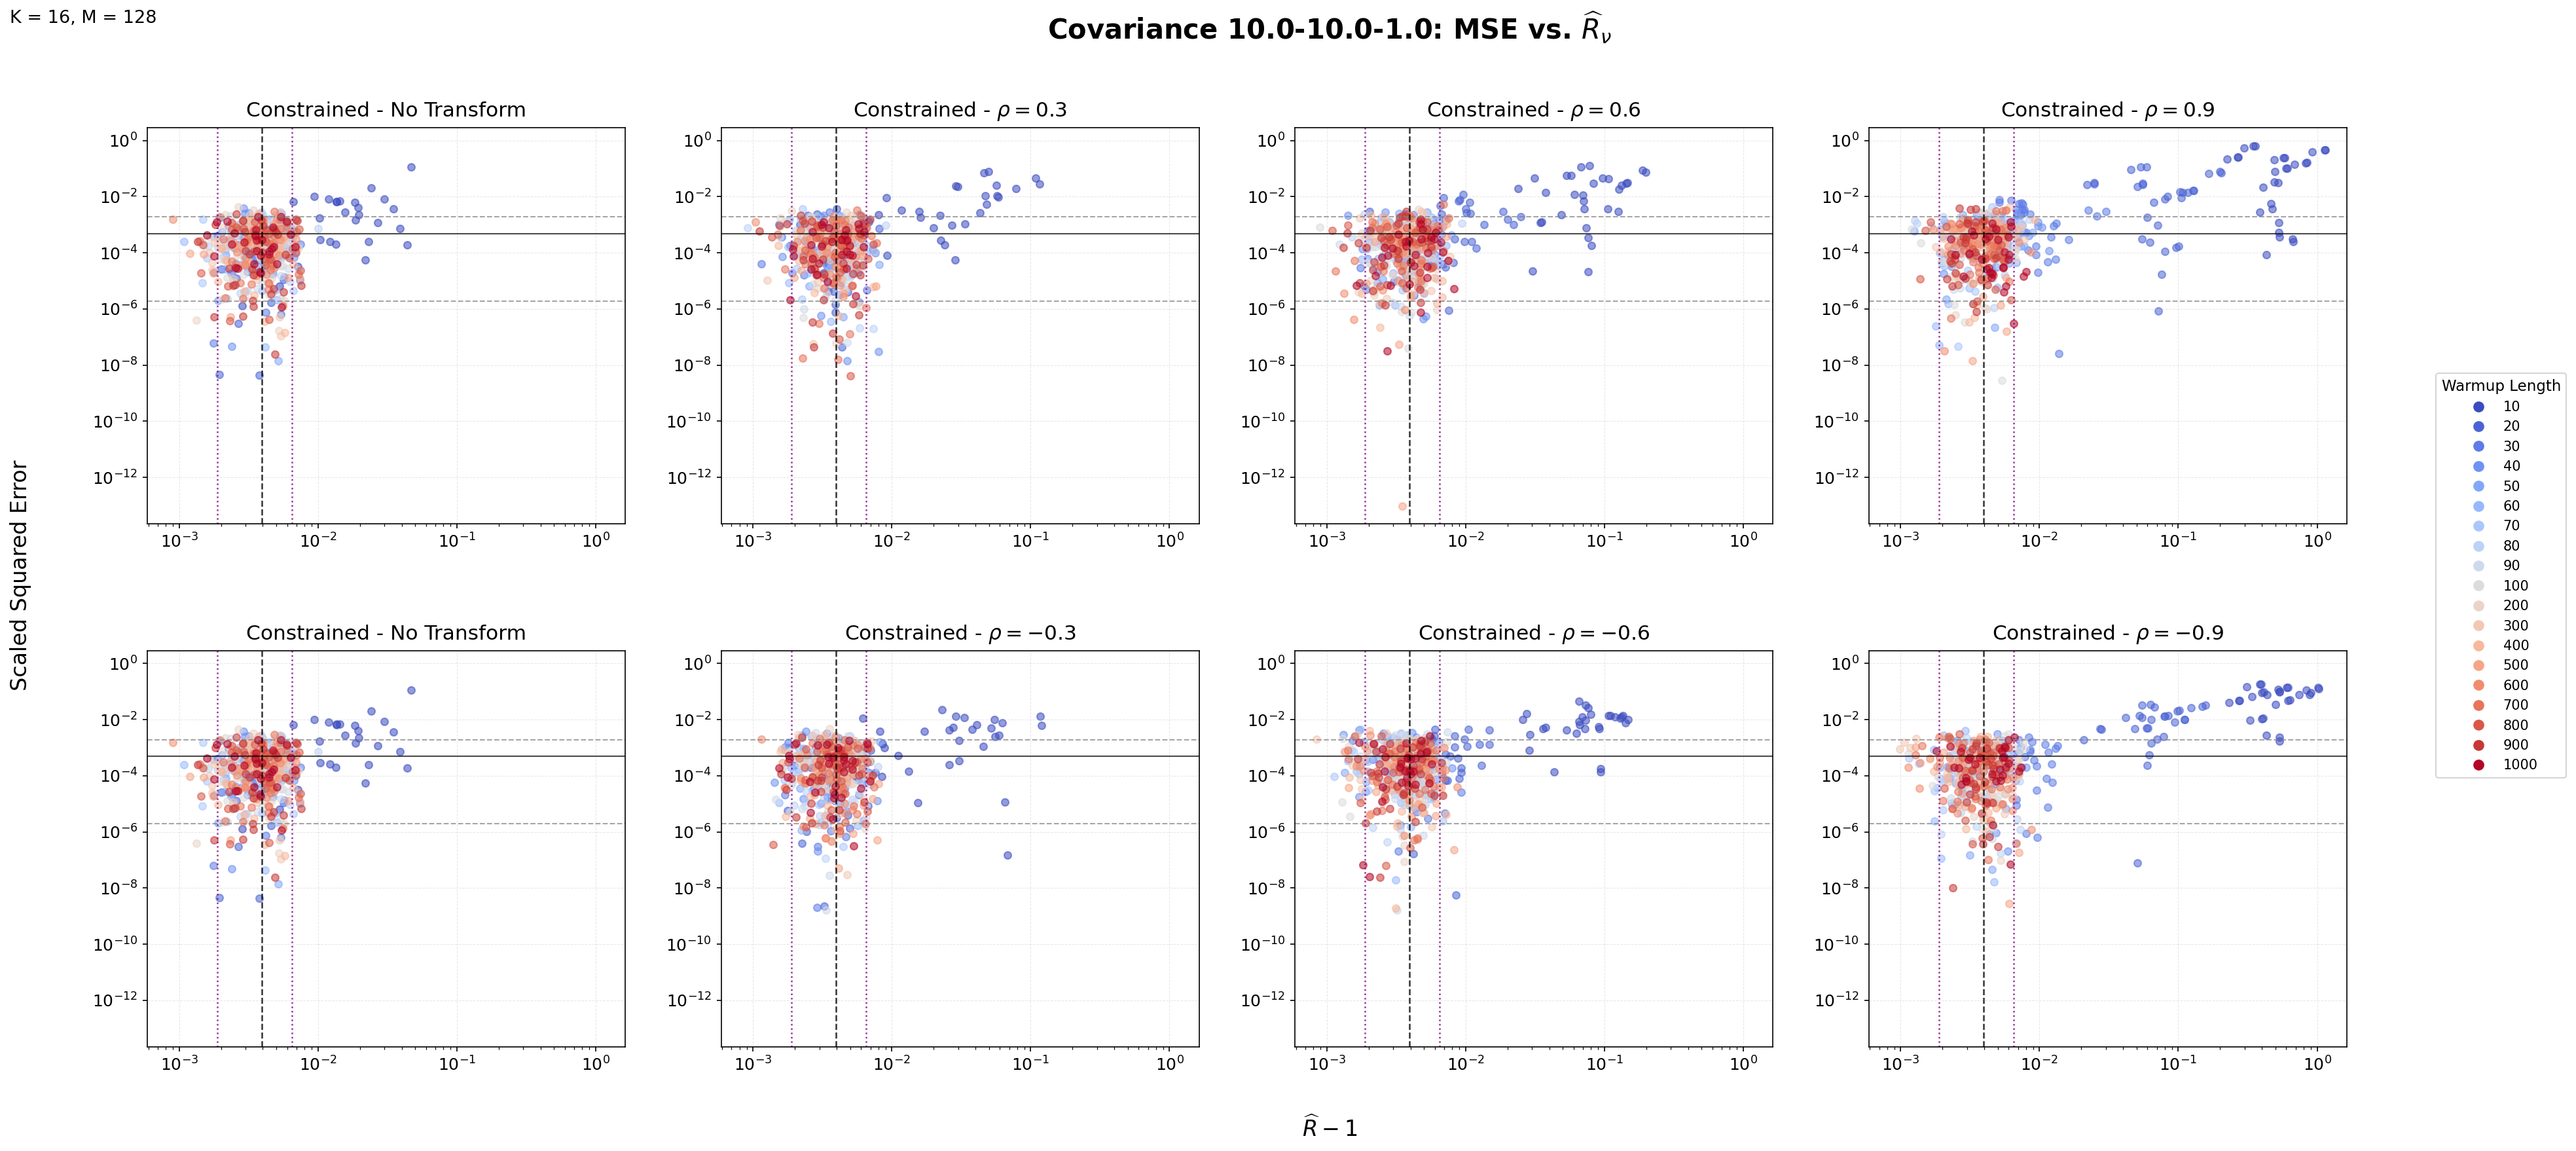

In [9]:
######################
# Load Data
######################

rho = 0.0
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")
print("Original Data Loaded!")

# rho = 0.3
rho = 0.3
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_03 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")


# rho = 0.6
rho = 0.6
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_06 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")


# rho = 0.9
rho = 0.9
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_09 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.3
rho = -0.3
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N03 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.6
rho = -0.6
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N06 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.9
rho = -0.9
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N09 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")
print("Transformed Data Loaded!")
######################
# Preset Dataframes
######################
dfs = [R_hat_c_df, R_hat_c_df_03, R_hat_c_df_06, R_hat_c_df_09,
       R_hat_c_df, R_hat_c_df_N03, R_hat_c_df_N06, R_hat_c_df_N09]
######################
# Plot
######################
MSE_vs_Rhat_8panel(dfs, bound, threshold, num_chains_short, num_super_chains, supertitle=f"Covariance {var1}-{var2}-{var3}")

In [10]:
Warmup_List = [10, 20, 30, 40,50, 100, 200, 500, 1000]

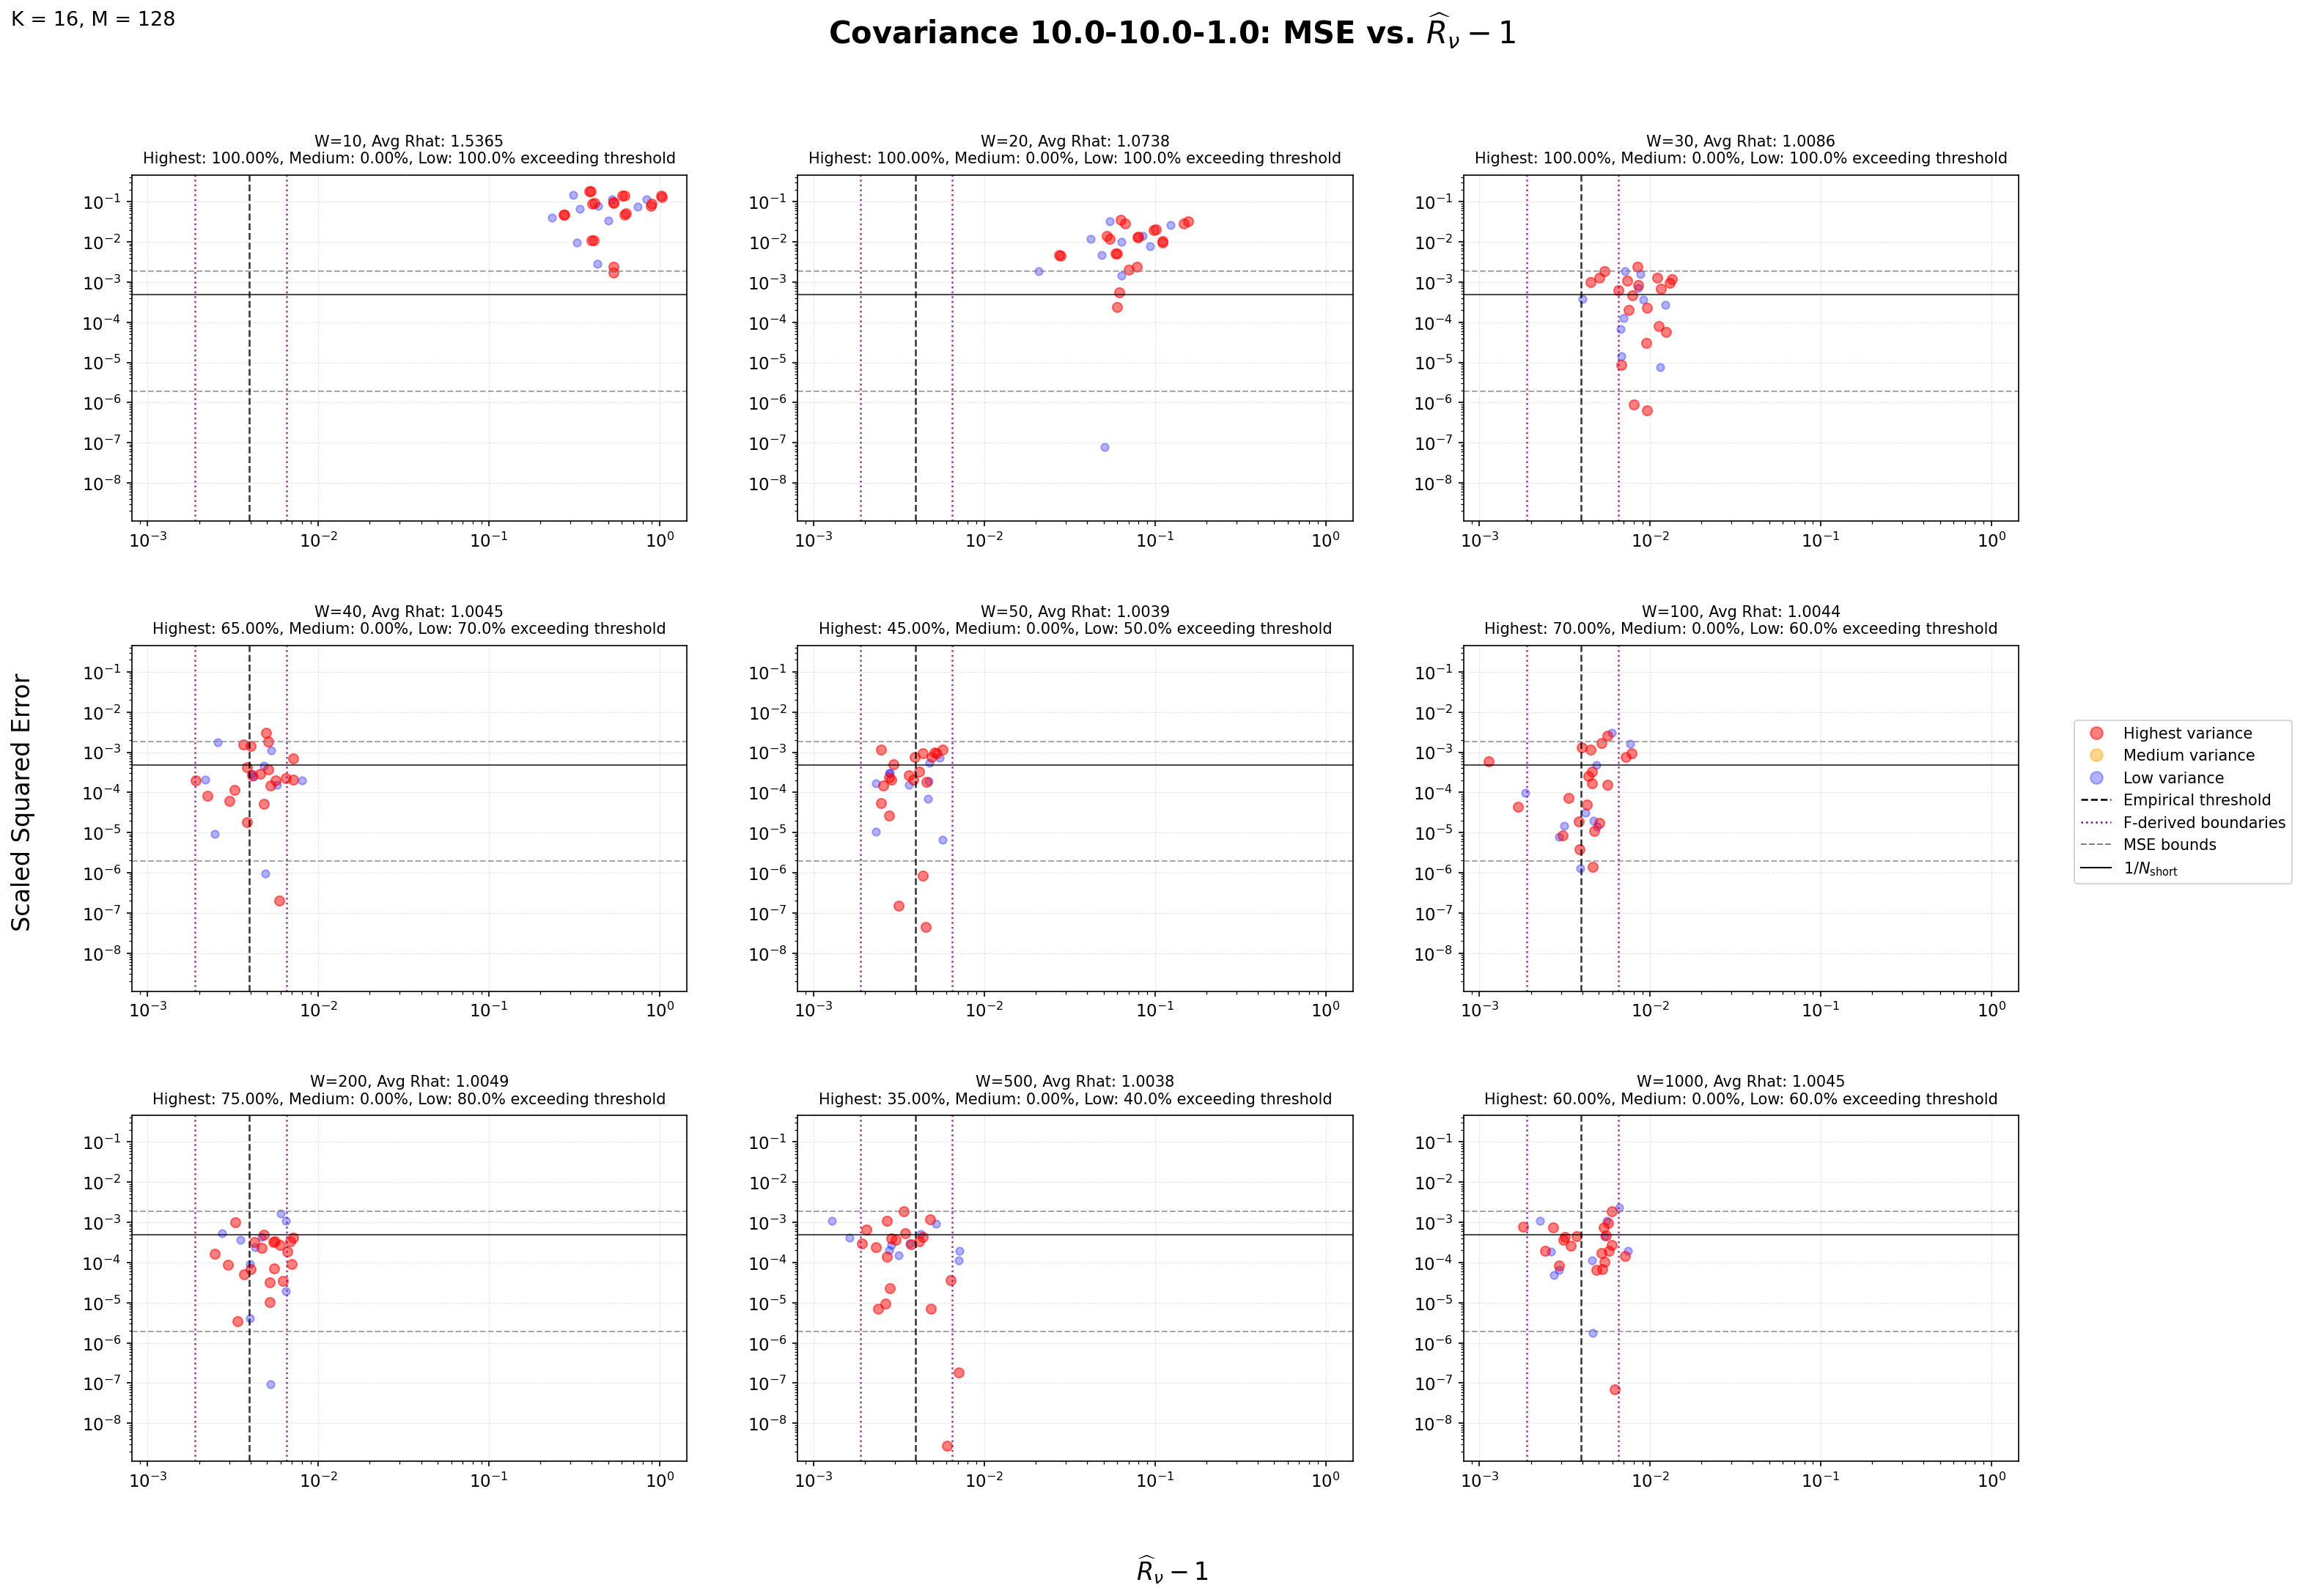

In [11]:
plot_mse_vs_rhat_9(
    f"Covariance {var1}-{var2}-{var3}",
    R_hat_c_df_N09,
    Warmup_List,
    [0,1],
    [],
    bound,
    threshold,
    num_chains_short,
    num_super_chains
)

#### **Distribution with covariance matrix**:
$$
\begin{bmatrix}
  100 & 100\rho & 10\rho^2 \\
  100\rho & 100 & 10\rho \\
  10\rho^2& 10\rho & 1 \\
\end{bmatrix}
$$

In [10]:
var1 = 100.0
var2 = 100.0
var3 = 1.0

Original Data Loaded!
Transformed Data Loaded!


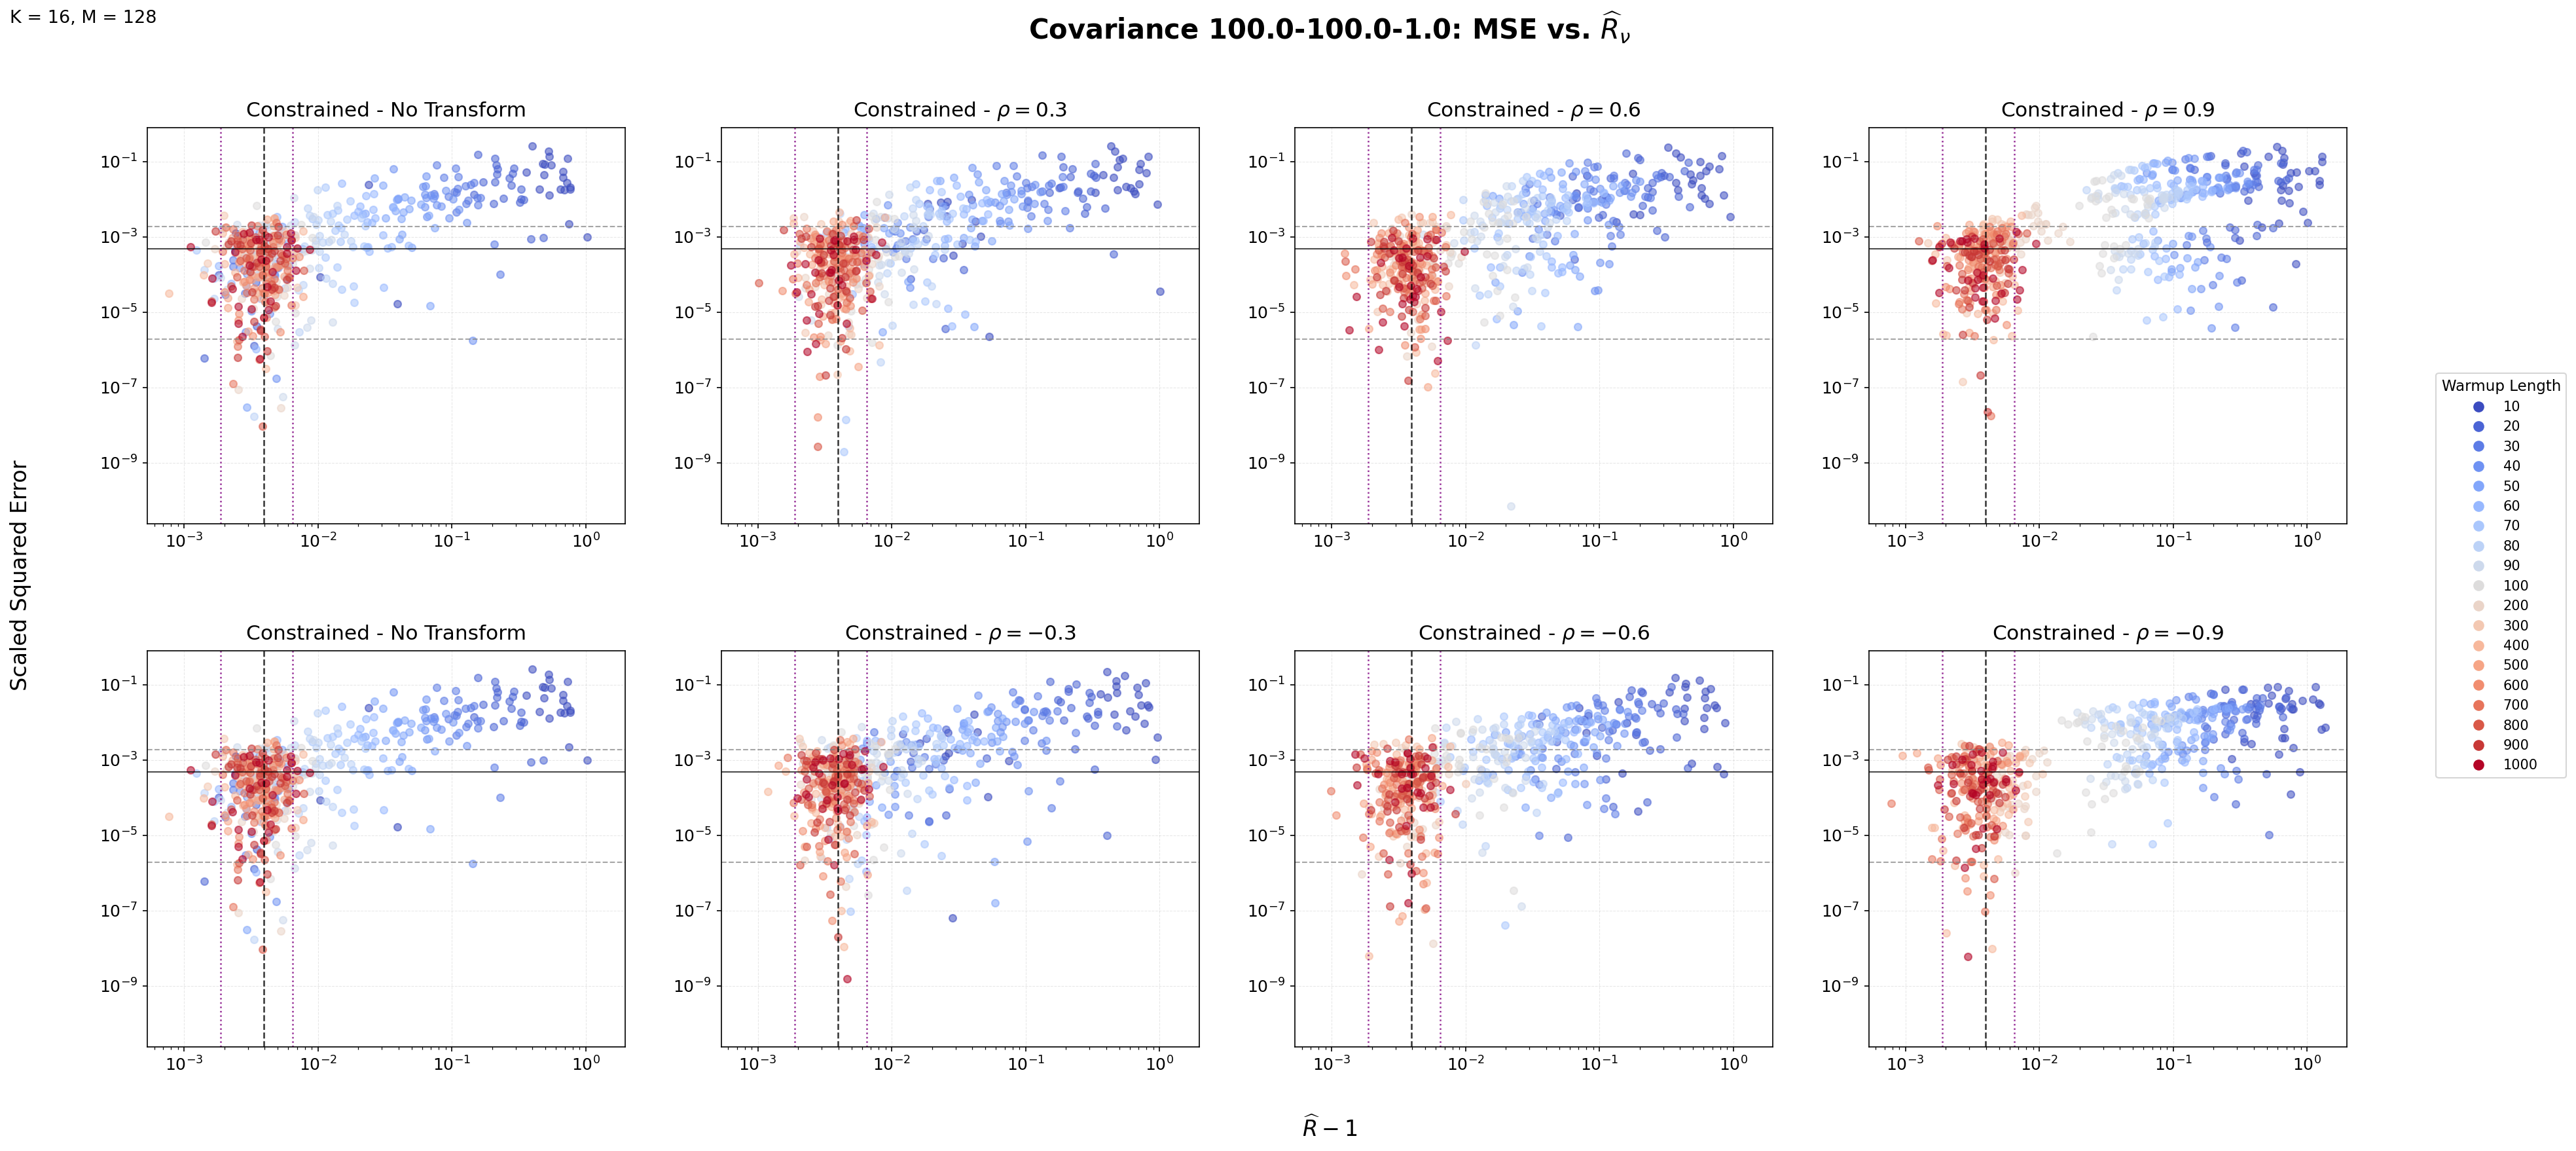

In [11]:
######################
# Load Data
######################

rho = 0.0
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")
print("Original Data Loaded!")

# rho = 0.3
rho = 0.3
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_03 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")


# rho = 0.6
rho = 0.6
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_06 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")


# rho = 0.9
rho = 0.9
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_09 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.3
rho = -0.3
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N03 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.6
rho = -0.6
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N06 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.9
rho = -0.9
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N09 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")
print("Transformed Data Loaded!")
######################
# Preset Dataframes
######################
dfs = [R_hat_c_df, R_hat_c_df_03, R_hat_c_df_06, R_hat_c_df_09,
       R_hat_c_df, R_hat_c_df_N03, R_hat_c_df_N06, R_hat_c_df_N09]
######################
# Plot
######################
MSE_vs_Rhat_8panel(dfs, bound, threshold, num_chains_short, num_super_chains, supertitle=f"Covariance {var1}-{var2}-{var3}")

#### **Distribution with covariance matrix**:
$$
\begin{bmatrix}
  100 & 100\rho & 10\rho^2 \\
  100\rho & 10 & 10\rho \\
  10\rho^2& 10\rho & 1 \\
\end{bmatrix}
$$

In [12]:
var1 = 100.0
var2 = 10.0
var3 = 1.0

Original Data Loaded!
Transformed Data Loaded!


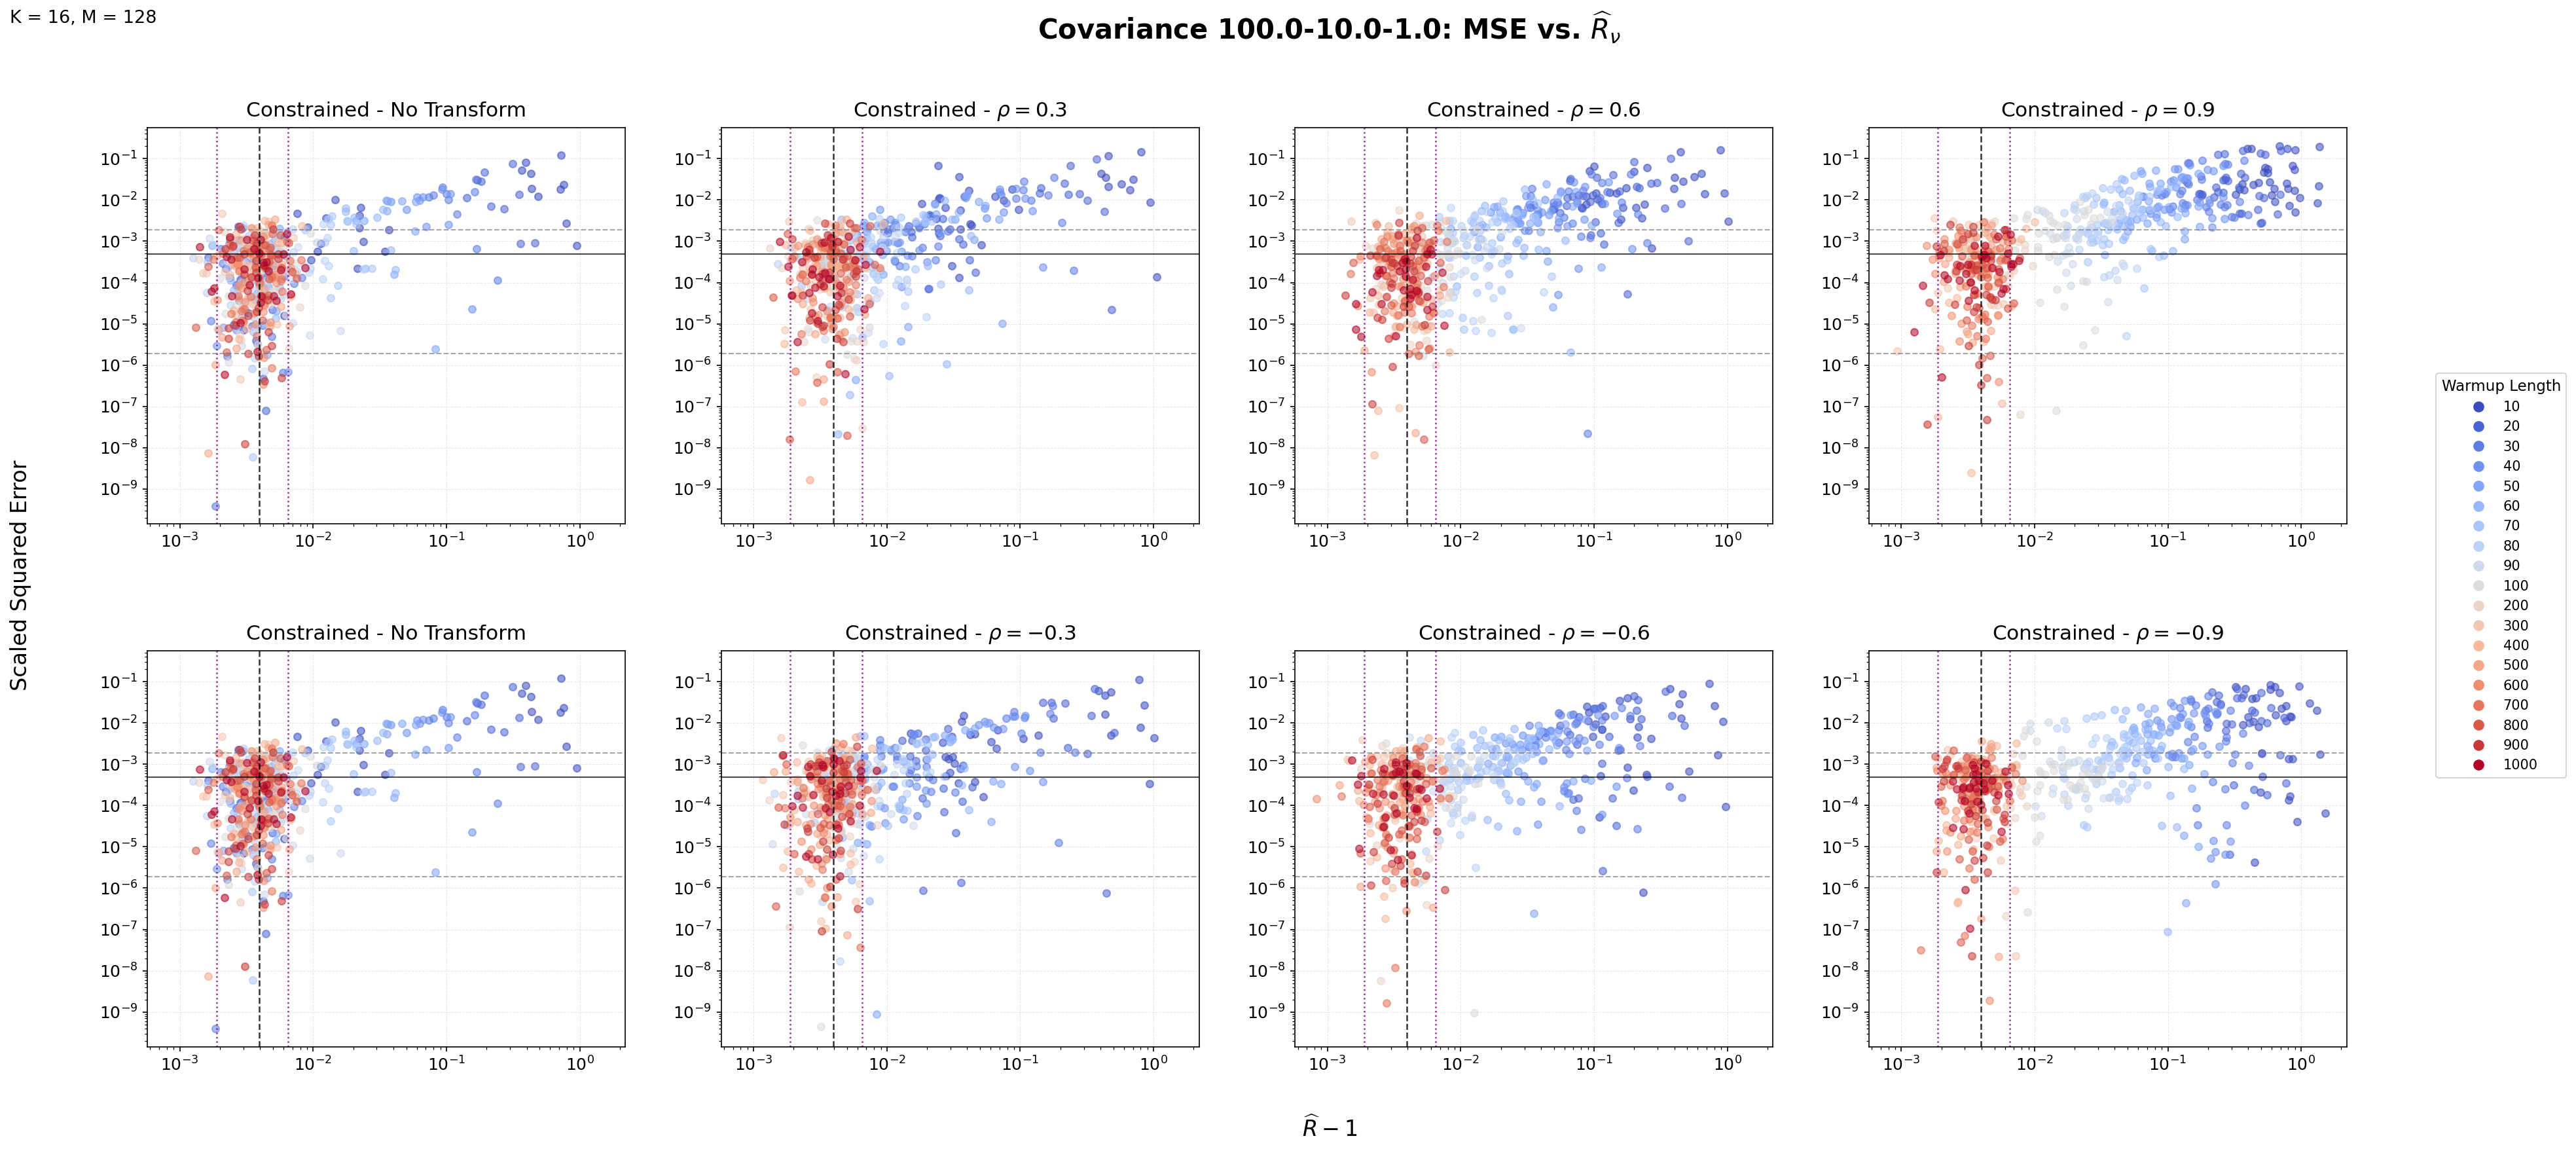

In [13]:
######################
# Load Data
######################

rho = 0.0
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")
print("Original Data Loaded!")

# rho = 0.3
rho = 0.3
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_03 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")


# rho = 0.6
rho = 0.6
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_06 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")


# rho = 0.9
rho = 0.9
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_09 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.3
rho = -0.3
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N03 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.6
rho = -0.6
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N06 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.9
rho = -0.9
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N09 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")
print("Transformed Data Loaded!")
######################
# Preset Dataframes
######################
dfs = [R_hat_c_df, R_hat_c_df_03, R_hat_c_df_06, R_hat_c_df_09,
       R_hat_c_df, R_hat_c_df_N03, R_hat_c_df_N06, R_hat_c_df_N09]
######################
# Plot
######################
MSE_vs_Rhat_8panel(dfs, bound, threshold, num_chains_short, num_super_chains, supertitle=f"Covariance {var1}-{var2}-{var3}")

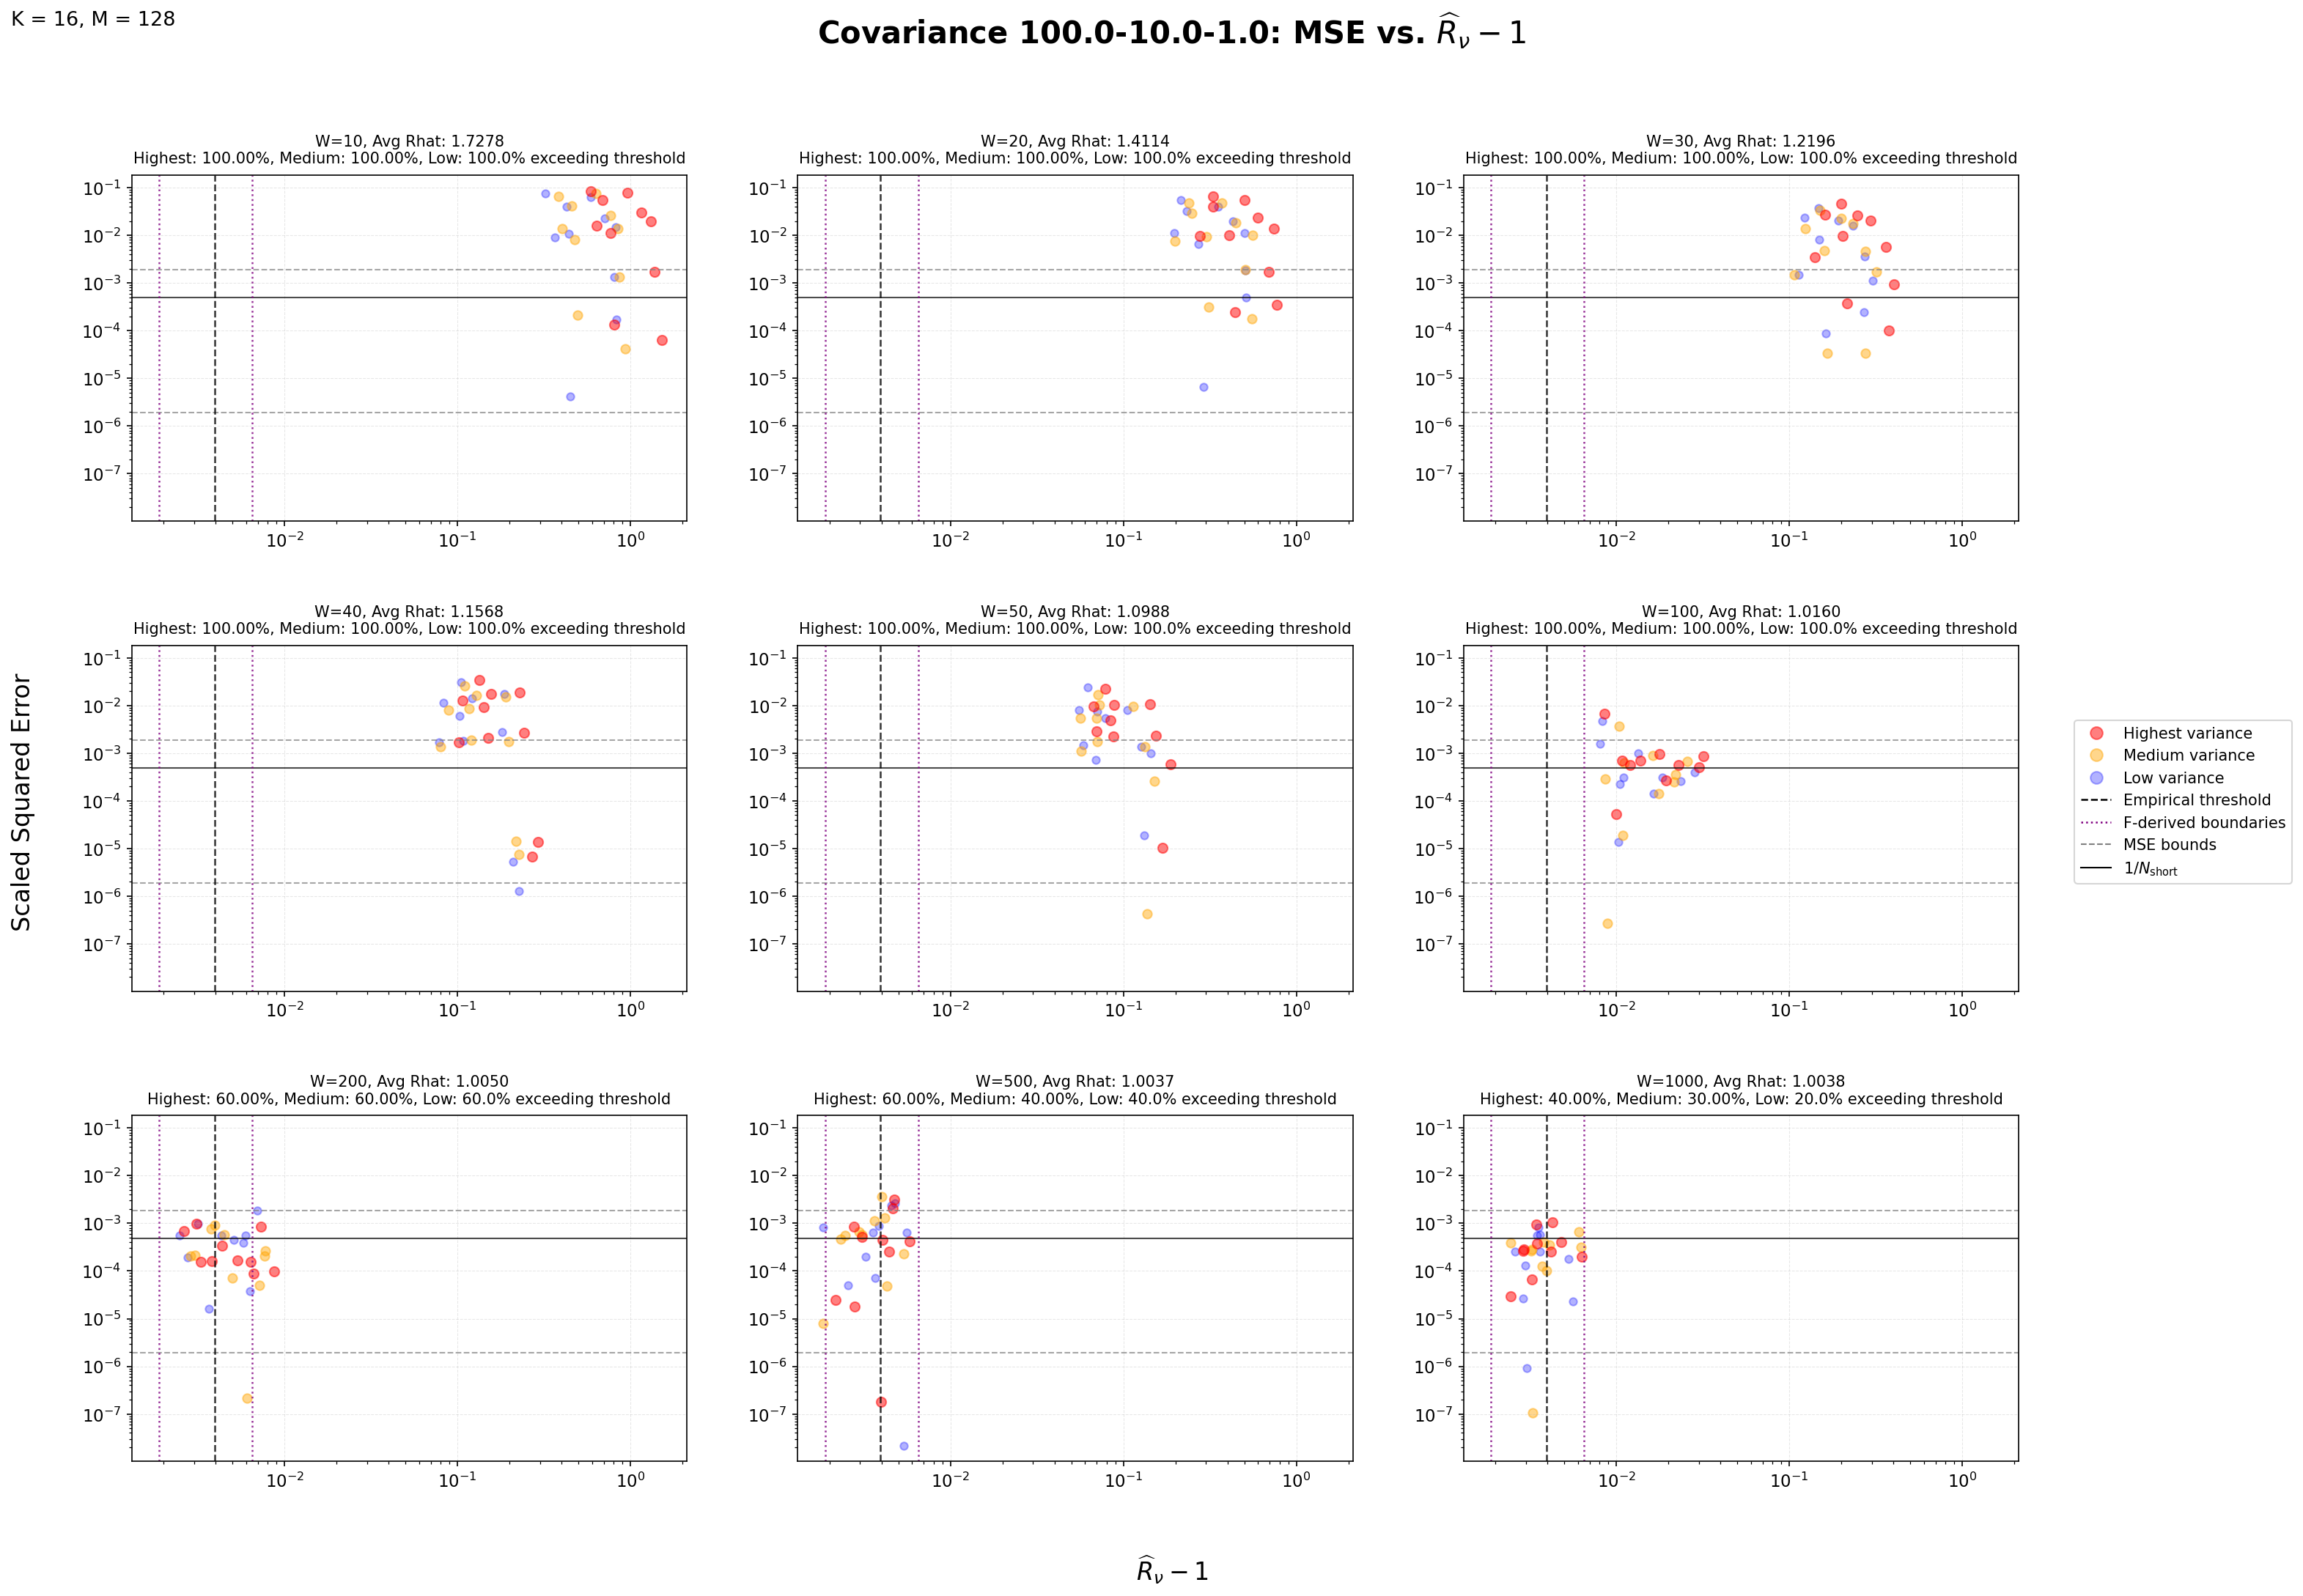

In [14]:
plot_mse_vs_rhat_9(
    f"Covariance {var1}-{var2}-{var3}",
    R_hat_c_df_N09,
    Warmup_List,
    [0],
    [1],
    bound,
    threshold,
    num_chains_short,
    num_super_chains
)

#### **Distribution with covariance matrix**:
$$
\begin{bmatrix}
  1000 & 100\rho & 10\rho^2 \\
  100\rho & 100 & 10\rho \\
  10\rho^2& 10\rho & 1 \\
\end{bmatrix}
$$

In [15]:
var1 = 1000.0
var2 = 100.0
var3 = 1.0

Original Data Loaded!
Transformed Data Loaded!


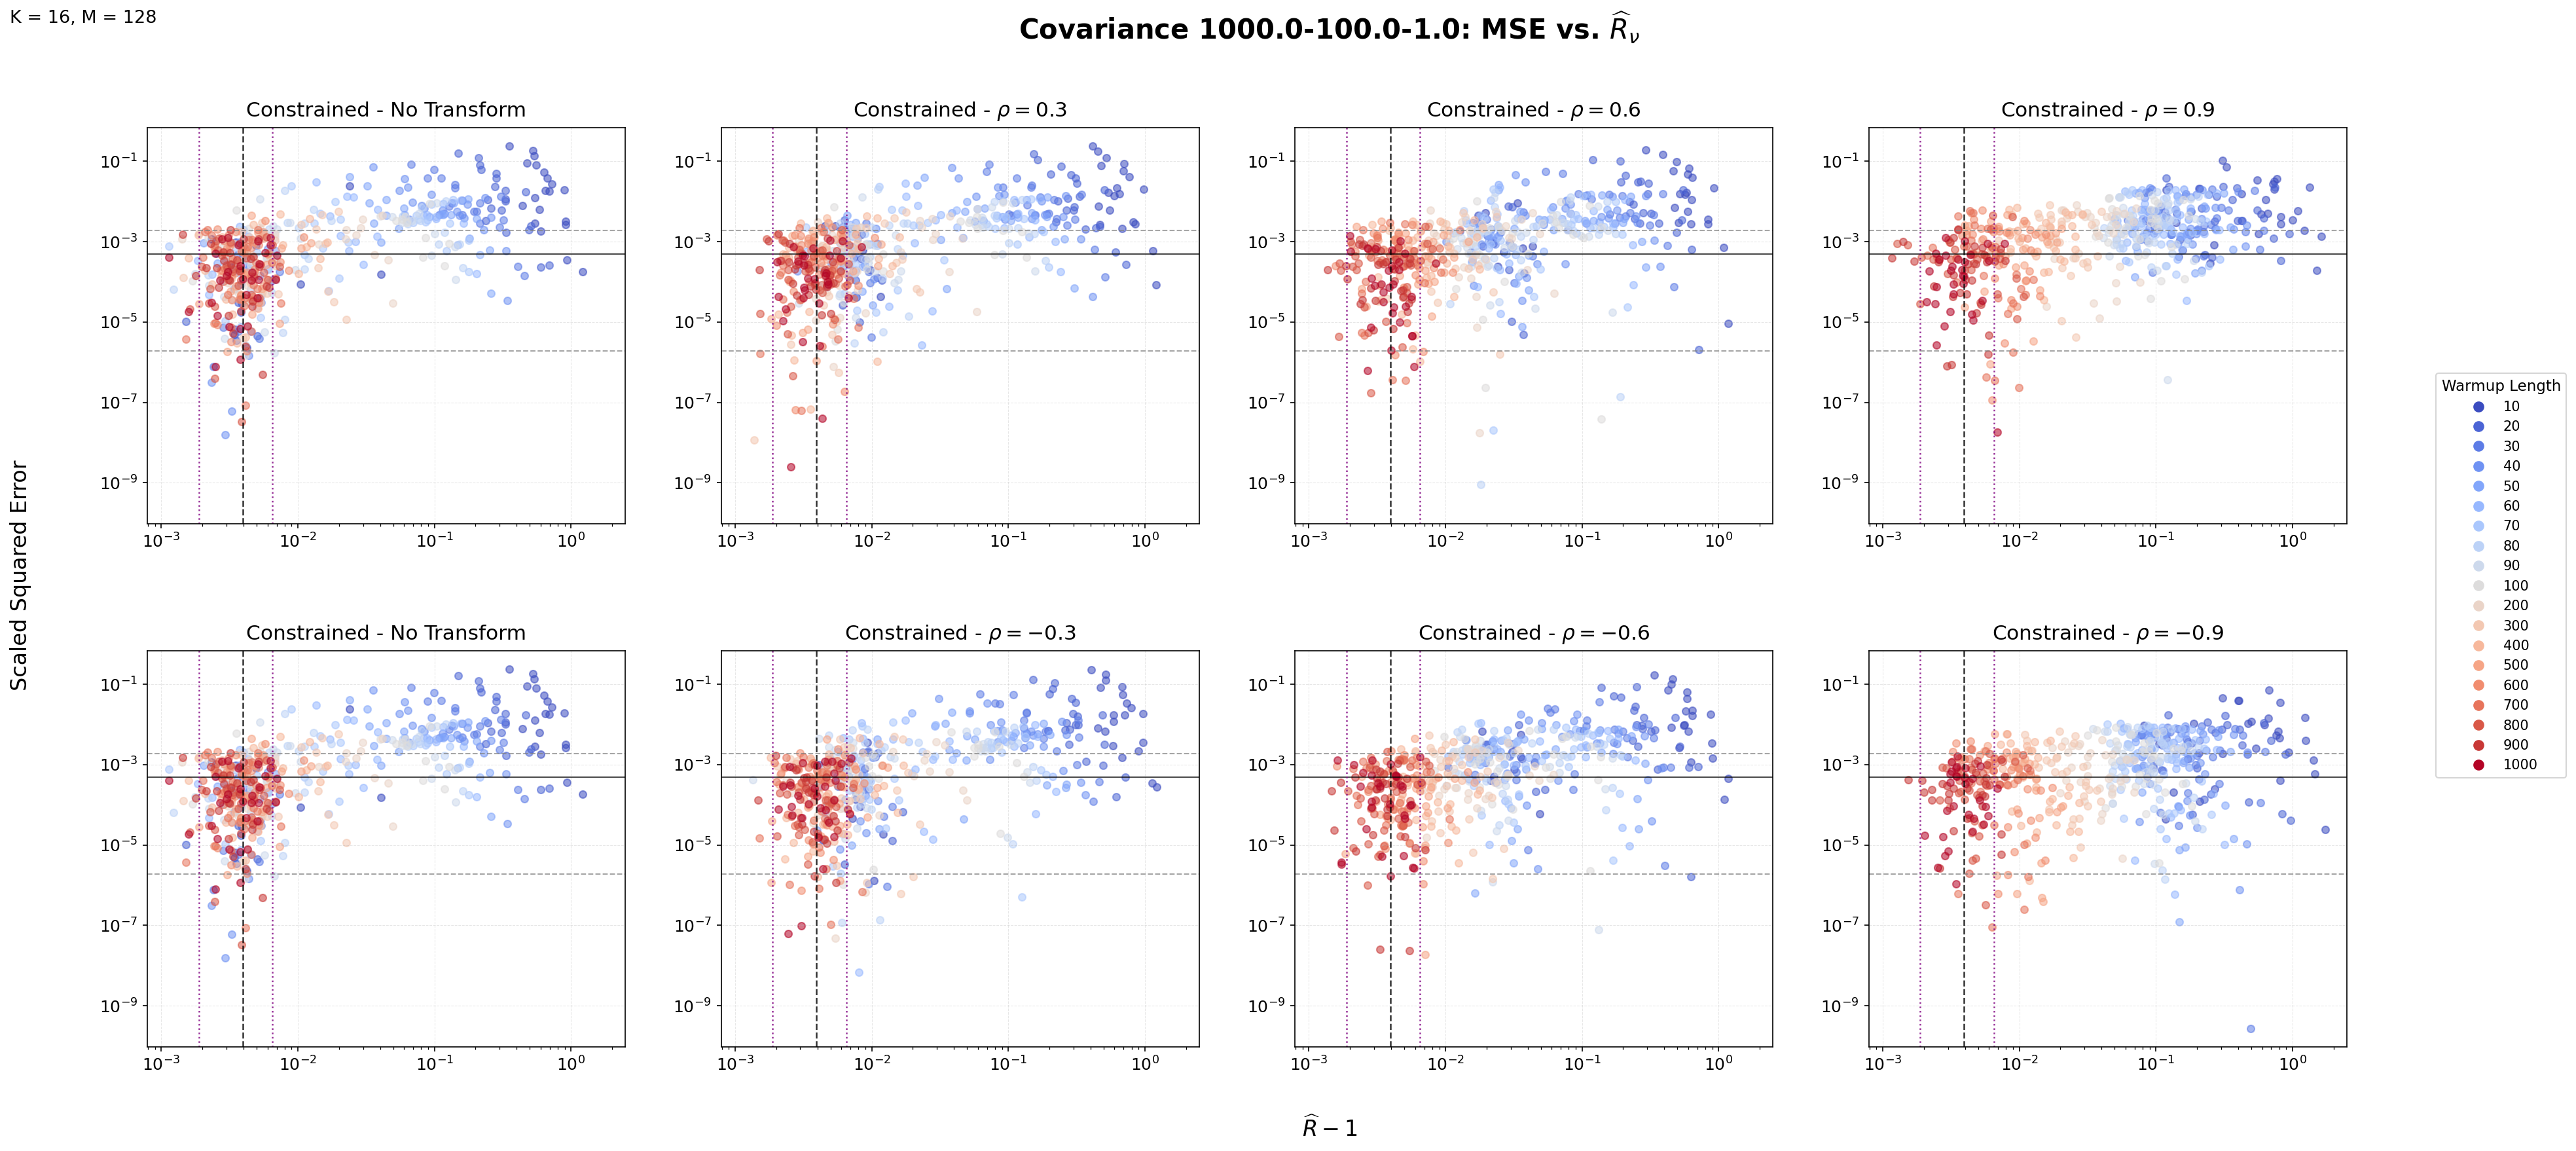

In [16]:
######################
# Load Data
######################

rho = 0.0
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")
print("Original Data Loaded!")

# rho = 0.3
rho = 0.3
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_03 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")


# rho = 0.6
rho = 0.6
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_06 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")


# rho = 0.9
rho = 0.9
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_09 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.3
rho = -0.3
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N03 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.6
rho = -0.6
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N06 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")

# rho = -0.9
rho = -0.9
label =f"var1_{var1:g}_var2_{var2:g}_var3_{var3:g}_rho_{rho:g}"
R_hat_c_df_N09 = pd.read_pickle(f"{save_dir}/{label}_Rhat_c.pkl")
print("Transformed Data Loaded!")
######################
# Preset Dataframes
######################
dfs = [R_hat_c_df, R_hat_c_df_03, R_hat_c_df_06, R_hat_c_df_09,
       R_hat_c_df, R_hat_c_df_N03, R_hat_c_df_N06, R_hat_c_df_N09]
######################
# Plot
######################
MSE_vs_Rhat_8panel(dfs, bound, threshold, num_chains_short, num_super_chains, supertitle=f"Covariance {var1}-{var2}-{var3}")

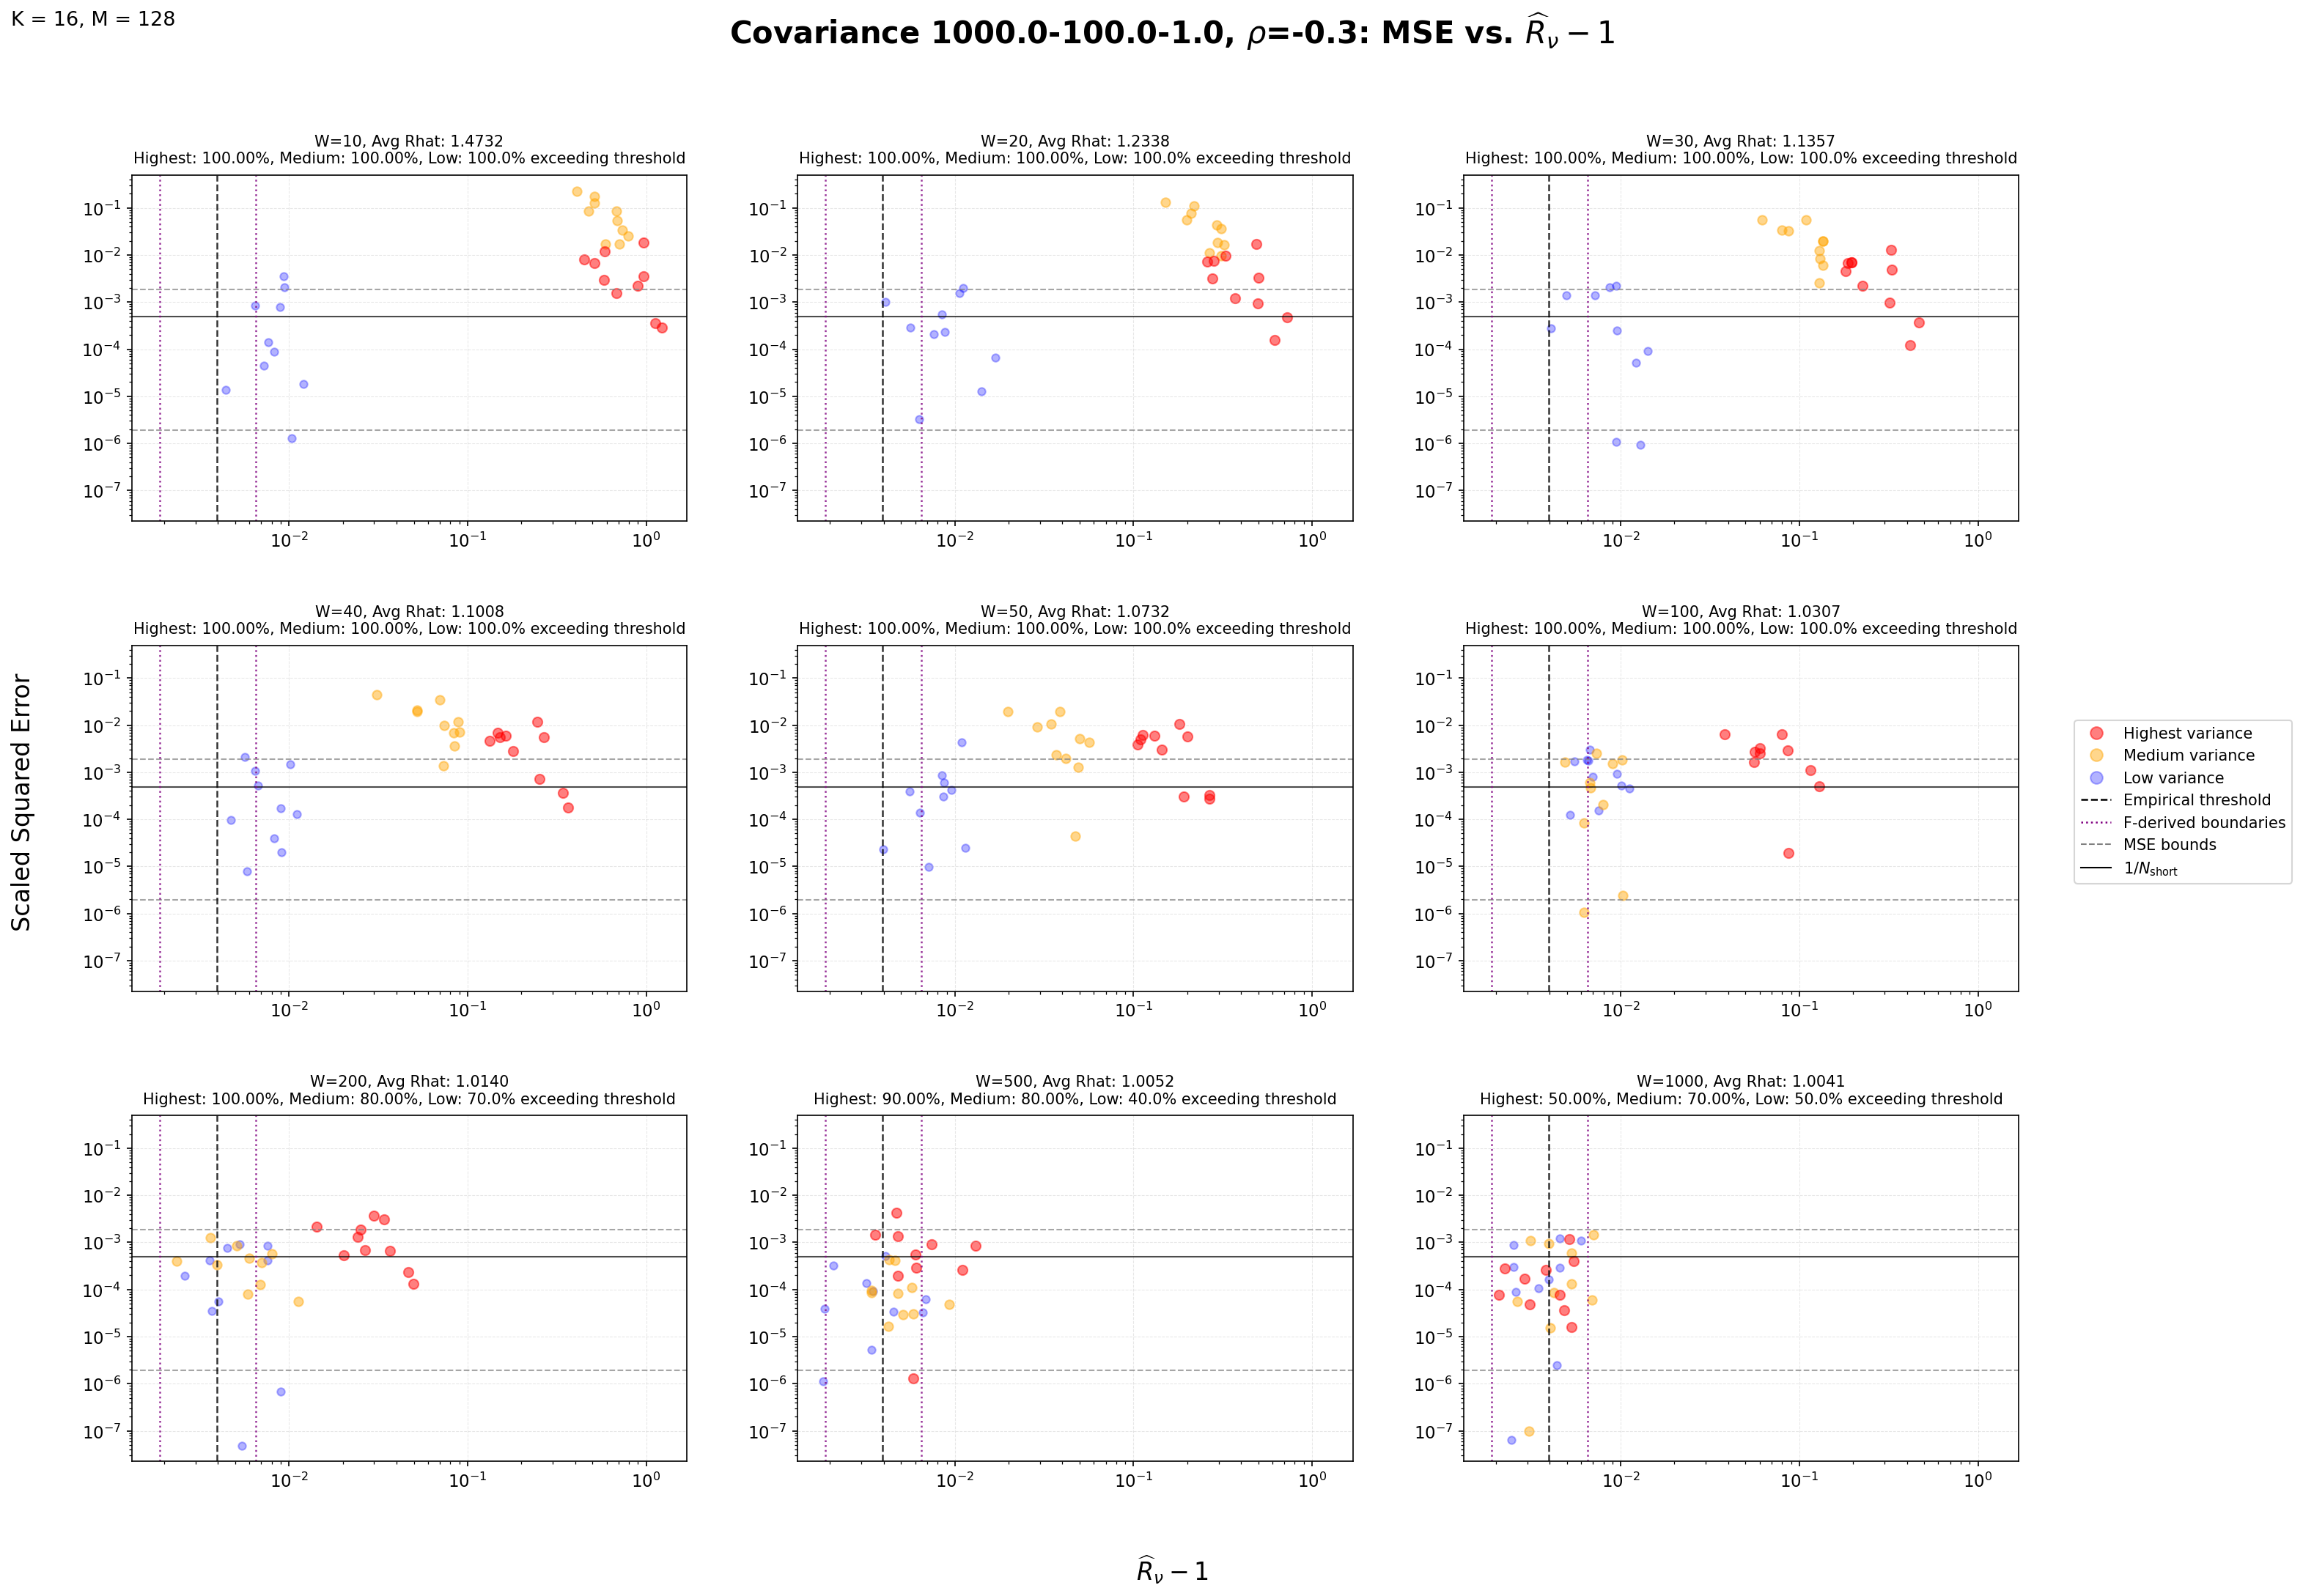

In [22]:
plot_mse_vs_rhat_9(
    f"Covariance {var1}-{var2}-{var3}, $\\rho$=-0.3",
    R_hat_c_df_N03,
    Warmup_List,
    [0],
    [1],
    bound,
    threshold,
    num_chains_short,
    num_super_chains
)